In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.model_selection import (train_test_split, GridSearchCV, cross_val_score)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor)

from xgboost import XGBRegressor

from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error)

In [2]:
df = pd.read_csv(r"C:\Users\HP 650 G5\Documents\WindowsPowerShell\insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### Data Cleaning

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


##### The columns format is correct

In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.isna().mean()*100

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

In [8]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Exploratory Data Analysis

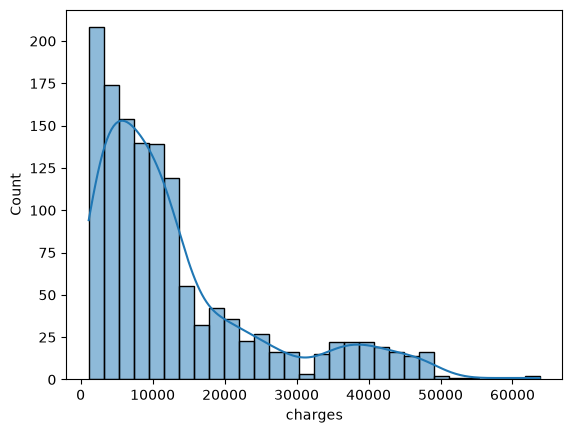

In [9]:
#distribution of insurance charges
sns.histplot(df['charges'], kde=True)

plt.show()

##### The distribution of insurance charges is right-skewed, with most observations concentrated at lower to moderate charge levels and fewer observations at higher charge levels.

In [10]:
average_charge = df.groupby('smoker')['charges'].mean().reset_index()
average_charge

,smoker,charges
0,no,8434.268298
1,yes,32050.231832


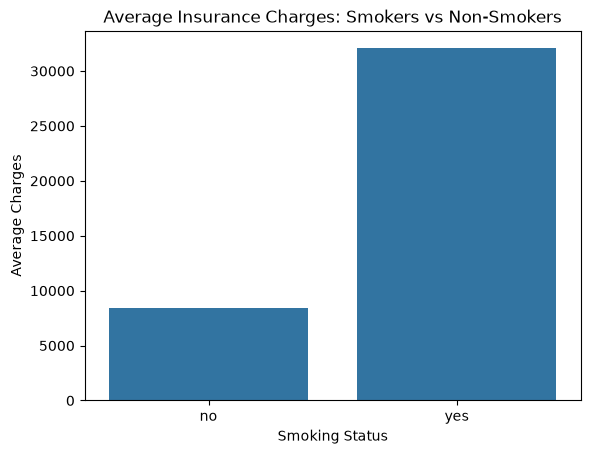

In [11]:
sns.barplot(data=average_charge, x="smoker", y="charges")

plt.title("Average Insurance Charges: Smokers vs Non-Smokers")
plt.xlabel("Smoking Status")
plt.ylabel("Average Charges")

plt.show()

##### Smokers have substantially higher average insurance charges than non-smokers, indicating that smoking status is an important predictor of insurance charges.

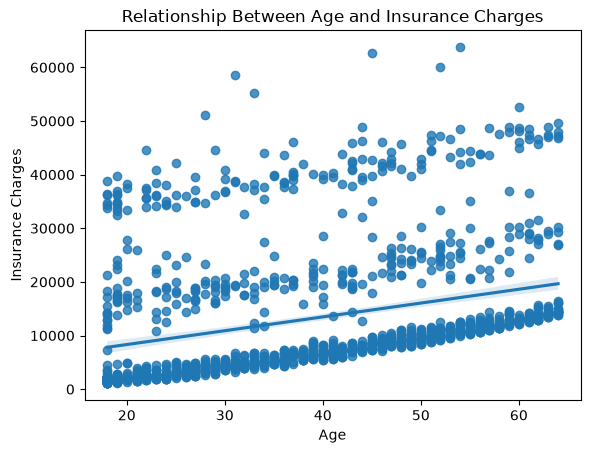

In [12]:
sns.regplot(data=df, x='age', y='charges')

plt.title('Relationship Between Age and Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Insurance Charges')

plt.show()

##### As age increase, insurance charges tend to increase

In [13]:
df[['age', 'charges']].corr()

,age,charges
age,1.000000,0.299008
charges,0.299008,1.000000


##### Age has a moderate positive correlation with insurance charges.

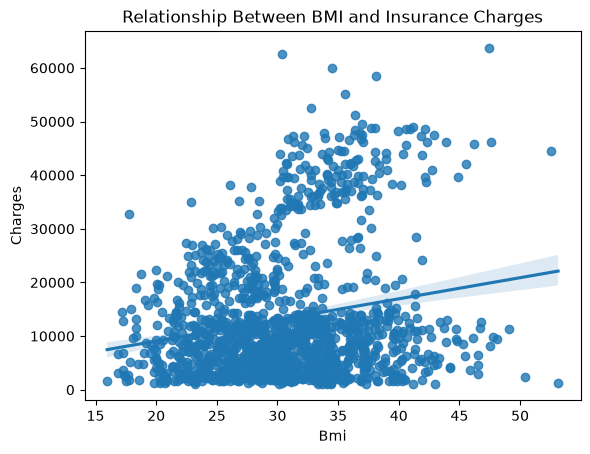

In [14]:
sns.regplot(data=df, x='bmi', y='charges')
plt.title('Relationship Between BMI and Insurance Charges')
plt.xlabel('Bmi')
plt.ylabel('Charges')

plt.show()

In [15]:
df[['bmi', 'charges']].corr()

,bmi,charges
bmi,1.000000,0.198341
charges,0.198341,1.000000


##### BMI has a weak positive correlation with insurance charges.

In [16]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Features and Target

In [17]:
# Define Features and Target

X = df.drop(columns=['charges'])
y = df['charges']

### Train/Test Split

In [18]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Machine Learning Modelling

#### Preprocessing

In [19]:
numerical_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numerical_features),('cat', OneHotEncoder(handle_unknown='ignore'), 
                                                                 categorical_features)])

#### Model 1 — Linear Regression.

In [20]:
linear_model = Pipeline(steps=[ ('preprocessor', preprocessor), ('model', LinearRegression())])

In [21]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the 

In [22]:
y_pred_linear = linear_model.predict(X_test)

In [23]:
r2_linear = r2_score(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)

print("Linear Regression")
print("R²:", r2_linear)
print("MAE:", mae_linear)
print("MSE:", mse_linear)
print("RMSE:", rmse_linear)

Linear Regression
R²: 0.7835929767120722
MAE: 4181.1944737536505
MSE: 33596915.851361476
RMSE: 5796.284659276274


#### Model 2 — Decision Tree Regressor

In [24]:
decision_tree_model = Pipeline(steps=[('preprocessor', preprocessor),('model', DecisionTreeRegressor(random_state=42))])

In [25]:
decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the 

In [26]:
y_pred_tree = decision_tree_model.predict(X_test)

In [27]:
r2_tree = r2_score(y_test, y_pred_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)

print("Decision Tree Regressor")
print("R²:", r2_tree)
print("MAE:", mae_tree)
print("MSE:", mse_tree)
print("RMSE:", rmse_tree)

Decision Tree Regressor
R²: 0.7135997956244222
MAE: 3227.6649542014925
MSE: 44463268.428293124
RMSE: 6668.0783159987795


#### Model 3 — Random Forest Regressor

In [28]:
random_forest_model = Pipeline(
    steps=[('preprocessor', preprocessor),('model', RandomForestRegressor(n_estimators=100, random_state=42))])

In [29]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the 

In [30]:
y_pred_rf = random_forest_model.predict(X_test)

In [31]:
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("Random Forest Regressor")
print("R²:", r2_rf)
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)

Random Forest Regressor
R²: 0.8645764547661136
MAE: 2545.869462487625
MSE: 21024333.61167968
RMSE: 4585.229940982205


#### Model 4 — XGBoost

In [32]:
xgb_model = Pipeline(
    steps=[('preprocessor', preprocessor),
        ('model', XGBRegressor(n_estimators=100,learning_rate=0.1, max_depth=3,random_state=42))])

In [33]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the 

In [34]:
y_pred_xgb = xgb_model.predict(X_test)

In [35]:
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print("XGBoost Regressor")
print("R²:", r2_xgb)
print("MAE:", mae_xgb)
print("MSE:", mse_xgb)
print("RMSE:", rmse_xgb)

XGBoost Regressor
R²: 0.8835411990531644
MAE: 2405.0586404172113
MSE: 18080081.118049182
RMSE: 4252.067863763369


#### Model 5 — Gradient Boosting Regressor

In [36]:
gradient_boosting_model = Pipeline(
    steps=[('preprocessor', preprocessor),('model', GradientBoostingRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,
                                                                              random_state=42))])

In [37]:
gradient_boosting_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the 

In [38]:
y_pred_gb = gradient_boosting_model.predict(X_test)

In [39]:
r2_gb = r2_score(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)

print("Gradient Boosting Regressor")
print("R²:", r2_gb)
print("MAE:", mae_gb)
print("MSE:", mse_gb)
print("RMSE:", rmse_gb)

Gradient Boosting Regressor
R²: 0.8795356375706068
MAE: 2400.758193112702
MSE: 18701939.457128547
RMSE: 4324.573904690327


In [40]:
models = {
    'Linear Regression': linear_model,
    'Decision Tree': decision_tree_model,
    'Random Forest': random_forest_model,
    'XGBoost': xgb_model,
    'Gradient Boosting': gradient_boosting_model}

In [41]:
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    cv_results[name] = scores
    print(name)
    print("R² scores:", scores)
    print("Mean R²:", scores.mean())
    print("Standard deviation:", scores.std())
    print()

Linear Regression
R² scores: [0.71585461 0.80210564 0.72296123 0.65784333 0.76678575]
Mean R²: 0.7331101109097584
Standard deviation: 0.04890863158789747

Decision Tree
R² scores: [0.7376117  0.73286342 0.62291235 0.64075597 0.76442203]
Mean R²: 0.6997130931552483
Standard deviation: 0.05673938821134953

Random Forest
R² scores: [0.81906816 0.90220259 0.79853572 0.78591706 0.83589242]
Mean R²: 0.8283231896444205
Standard deviation: 0.04071041153375323

XGBoost
R² scores: [0.83612487 0.91490925 0.82411039 0.79336259 0.85112034]
Mean R²: 0.8439254889951897
Standard deviation: 0.04025060239066887

Gradient Boosting
R² scores: [0.83301788 0.91720806 0.82022321 0.7943049  0.84203308]
Mean R²: 0.8413574243137425
Standard deviation: 0.04119203455692693



In [42]:
cv_mae_linear = -cross_val_score(
    linear_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

cv_mae_tree = -cross_val_score(
    decision_tree_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

cv_mae_rf = -cross_val_score(
    random_forest_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

cv_mae_xgb = -cross_val_score(
    xgb_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

cv_mae_gb = -cross_val_score(
    gradient_boosting_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

print("Linear Regression Mean MAE:", cv_mae_linear.mean())
print("Decision Tree Mean MAE:", cv_mae_tree.mean())
print("Random Forest Mean MAE:", cv_mae_rf.mean())
print("XGBoost Mean MAE:", cv_mae_xgb.mean())
print("Gradient Boosting Mean MAE:", cv_mae_gb.mean())

Linear Regression Mean MAE: 4245.227947603455
Decision Tree Mean MAE: 3161.332277037383
Random Forest Mean MAE: 2735.6122359927804
XGBoost Mean MAE: 2631.41655051223
Gradient Boosting Mean MAE: 2674.418583729869


In [43]:
xgb_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [2, 3, 4]}

In [44]:
xgb_grid_search = GridSearchCV(estimator=xgb_model, param_grid=xgb_param_grid, cv=5, scoring='r2', n_jobs=-1)

xgb_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ver

In [45]:
print("Best Parameters:", xgb_grid_search.best_params_)
print("Best CV R²:", xgb_grid_search.best_score_)

Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV R²: 0.8483159080499943


In [46]:
tuned_xgb = xgb_grid_search.best_estimator_

tuned_xgb_pred = tuned_xgb.predict(X_test)

tuned_xgb_r2 = r2_score(y_test, tuned_xgb_pred)
tuned_xgb_mae = mean_absolute_error(y_test, tuned_xgb_pred)
tuned_xgb_rmse = np.sqrt(mean_squared_error(y_test, tuned_xgb_pred))

print("Tuned XGBoost R²:", tuned_xgb_r2)
print("Tuned XGBoost MAE:", tuned_xgb_mae)
print("Tuned XGBoost RMSE:", tuned_xgb_rmse)

Tuned XGBoost R²: 0.8842638716508351
Tuned XGBoost MAE: 2429.7187258125
Tuned XGBoost RMSE: 4238.854457748806


#### Tune Gradient Boosting

In [47]:
gb_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [2, 3, 4]}

In [48]:
gb_grid_search = GridSearchCV(
    estimator=gradient_boosting_model,
    param_grid=gb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1)

gb_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbo

In [49]:
print("Best Parameters:", gb_grid_search.best_params_)
print("Best CV R²:", gb_grid_search.best_score_)

Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100}
Best CV R²: 0.8488618524942071


In [50]:
tuned_gb = gb_grid_search.best_estimator_

tuned_gb_pred = tuned_gb.predict(X_test)

tuned_gb_r2 = r2_score(y_test, tuned_gb_pred)
tuned_gb_mae = mean_absolute_error(y_test, tuned_gb_pred)
tuned_gb_rmse = np.sqrt(mean_squared_error(y_test, tuned_gb_pred))

print("Tuned Gradient Boosting R²:", tuned_gb_r2)
print("Tuned Gradient Boosting MAE:", tuned_gb_mae)
print("Tuned Gradient Boosting RMSE:", tuned_gb_rmse)

Tuned Gradient Boosting R²: 0.8781452524361194
Tuned Gradient Boosting MAE: 2451.5120621842198
Tuned Gradient Boosting RMSE: 4349.45916011896


#### Random Forest tuning

In [51]:
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]}

In [52]:
rf_grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1)

rf_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ver

In [53]:
print("Best Parameters:", rf_grid_search.best_params_)
print("Best CV R²:", rf_grid_search.best_score_)

Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Best CV R²: 0.8395019392111788


In [54]:
tuned_rf = rf_grid_search.best_estimator_

tuned_rf_pred = tuned_rf.predict(X_test)

tuned_rf_r2 = r2_score(y_test, tuned_rf_pred)
tuned_rf_mae = mean_absolute_error(y_test, tuned_rf_pred)
tuned_rf_rmse = np.sqrt(mean_squared_error(y_test, tuned_rf_pred))

print("Tuned Random Forest R²:", tuned_rf_r2)
print("Tuned Random Forest MAE:", tuned_rf_mae)
print("Tuned Random Forest RMSE:", tuned_rf_rmse)

Tuned Random Forest R²: 0.8705685017617495
Tuned Random Forest MAE: 2524.5576901112663
Tuned Random Forest RMSE: 4482.641622589085


In [55]:
final_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Tuned Random Forest',
        'XGBoost',
        'Tuned XGBoost',
        'Gradient Boosting',
        'Tuned Gradient Boosting'],
    'CV R2': [0.7331,0.6997,0.8283,0.8395,0.8439,0.8483,0.8414,0.8489],
    'Test R2': [0.7836,0.7136,0.8646,0.8706,0.8835,0.8843,0.8795,0.8781],
    'Test MAE': [ 4181.19, 3227.66,2545.87, 2524.56,2405.06,2429.72,2400.76,2451.51],
    'Test RMSE': [5796.28,6668.08,4585.23,4482.64,4252.07,4238.85, 4324.57,4349.46]})

final_results

,Model,CV R2,Test R2,Test MAE,Test RMSE
0,Linear Regression,0.7331,0.7836,4181.19,5796.28
1,Decision Tree,0.6997,0.7136,3227.66,6668.08
2,Random Forest,0.8283,0.8646,2545.87,4585.23
3,Tuned Random Forest,0.8395,0.8706,2524.56,4482.64
4,XGBoost,0.8439,0.8835,2405.06,4252.07
5,Tuned XGBoost,0.8483,0.8843,2429.72,4238.85
6,Gradient Boosting,0.8414,0.8795,2400.76,4324.57
7,Tuned Gradient Boosting,0.8489,0.8781,2451.51,4349.46


#### Conclusion

##### Tuned XGBoost was selected as the final model because it achieved the strongest held-out R² and lowest RMSE, while Gradient Boosting produced the lowest MAE.

### Final Model Selection

In [56]:
feature_names = tuned_xgb.named_steps['preprocessor'].get_feature_names_out()

importance = tuned_xgb.named_steps['model'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False)

print(feature_importance)

                  Feature  Importance
5          cat__smoker_no    0.823807
1                num__bmi    0.102389
0                num__age    0.042627
2           num__children    0.009505
10  cat__region_southwest    0.006546
8   cat__region_northwest    0.005028
7   cat__region_northeast    0.004780
3         cat__sex_female    0.003106
9   cat__region_southeast    0.002213
4           cat__sex_male    0.000000
6         cat__smoker_yes    0.000000


In [57]:
explainer = shap.TreeExplainer(
    tuned_xgb.named_steps['model'])

In [58]:
X_test_transformed = tuned_xgb.named_steps['preprocessor'].transform(X_test)

In [59]:
feature_names = tuned_xgb.named_steps['preprocessor'].get_feature_names_out()

In [60]:
shap_values = explainer.shap_values(X_test_transformed)

In [61]:
print("SHAP values shape:", shap_values.shape)
print("Test data shape:", X_test_transformed.shape)

SHAP values shape: (268, 11)
Test data shape: (268, 11)


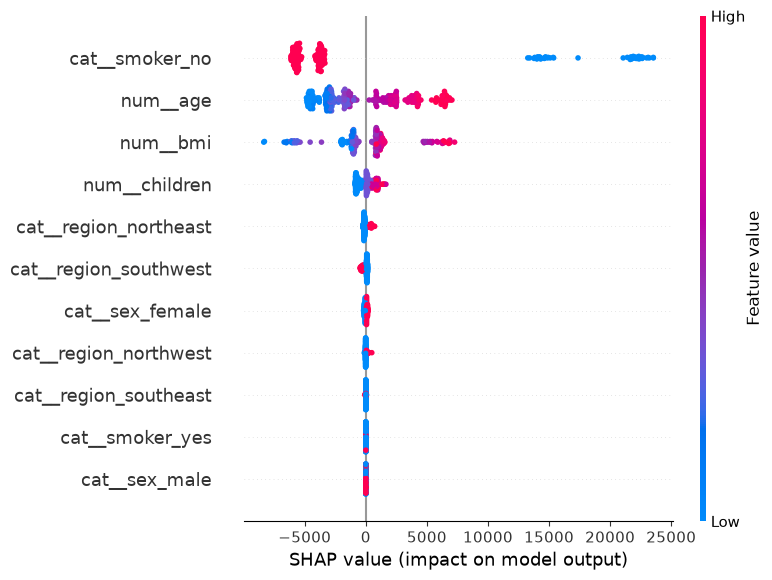

In [62]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=False)

plt.tight_layout()
plt.show()

In [63]:
shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Absolute_SHAP': np.abs(shap_values).mean(axis=0)})

shap_importance = shap_importance.sort_values(
    by='Mean_Absolute_SHAP',
    ascending=False)

print(shap_importance)

                  Feature  Mean_Absolute_SHAP
5          cat__smoker_no         7594.604004
0                num__age         3197.021973
1                num__bmi         2067.710938
2           num__children          557.570374
7   cat__region_northeast          182.105316
10  cat__region_southwest          124.706757
3         cat__sex_female           88.725639
8   cat__region_northwest           31.177647
9   cat__region_southeast            4.626160
4           cat__sex_male            0.000000
6         cat__smoker_yes            0.000000


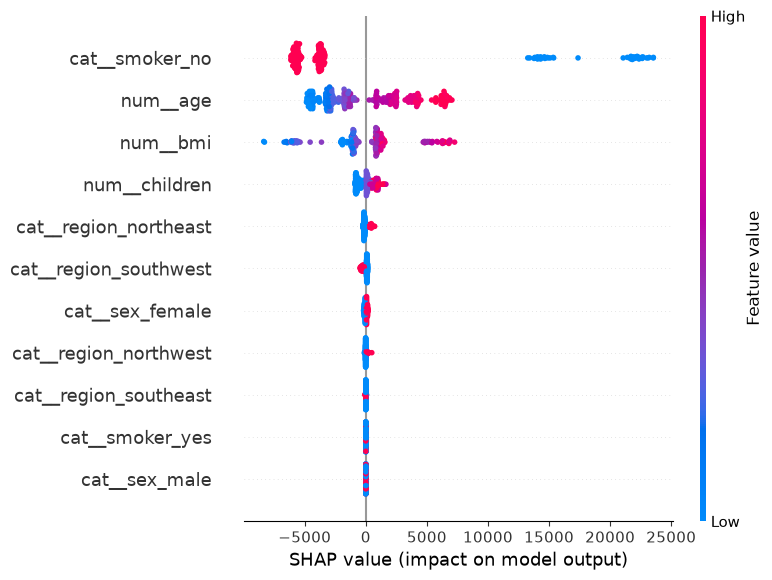

In [64]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="dot")

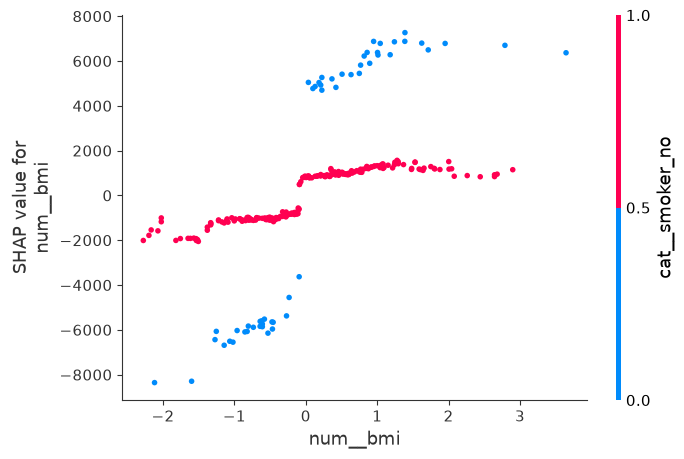

In [65]:
shap.dependence_plot(
    "num__bmi",
    shap_values,
    X_test_transformed,
    feature_names=feature_names)

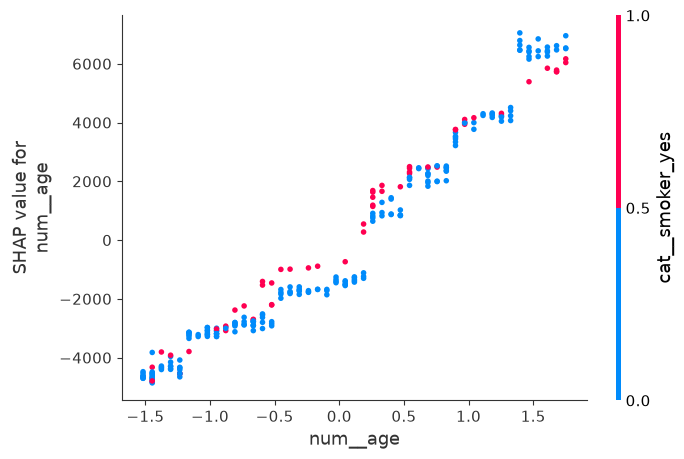

In [66]:
shap.dependence_plot(
    "num__age",
    shap_values,
    X_test_transformed,
    feature_names=feature_names)

In [67]:
tuned_xgb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the 

In [68]:
tuned_xgb_pred = tuned_xgb.predict(X_test)

print("Final Model: Tuned XGBoost")
print(f"R²:   {r2_score(y_test, tuned_xgb_pred):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, tuned_xgb_pred):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, tuned_xgb_pred)):,.2f}")

Final Model: Tuned XGBoost
R²:   0.8843
MAE:  2,429.72
RMSE: 4,238.85


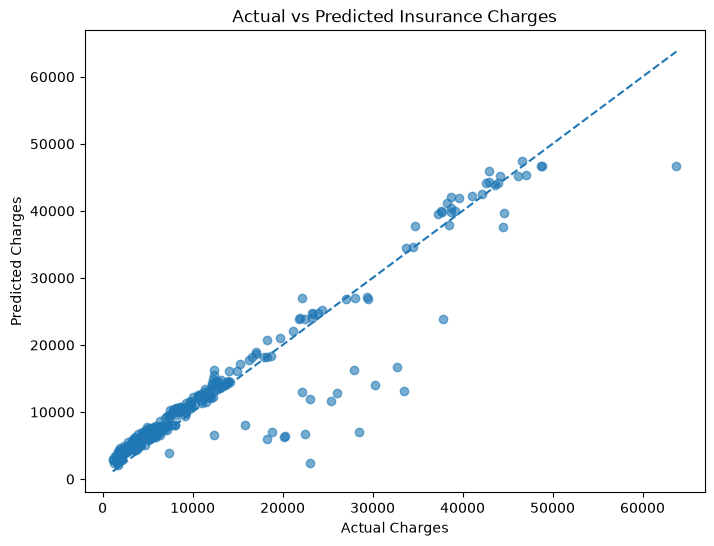

In [69]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, tuned_xgb_pred, alpha=0.6)

plt.plot( [y_test.min(), y_test.max()], [y_test.min(), y_test.max()],linestyle='--')

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.show()

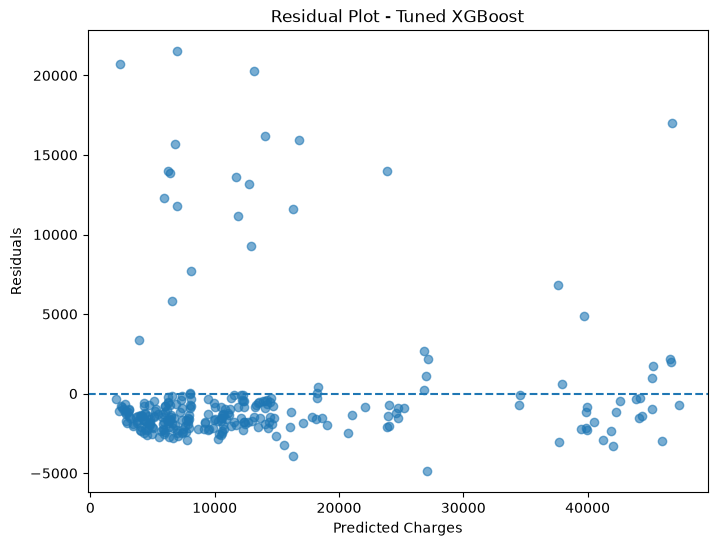

In [70]:
residuals = y_test - tuned_xgb_pred

plt.figure(figsize=(8, 6))

plt.scatter(tuned_xgb_pred, residuals, alpha=0.6)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot - Tuned XGBoost")

plt.show()

### Final Conclusion

This project developed a machine learning model to predict individual medical insurance charges using demographic and health-related features.

The analysis began with data cleaning and exploratory data analysis, followed by preprocessing of numerical and categorical variables. Five regression algorithms were evaluated: Linear Regression, Decision Tree, Random Forest, XGBoost, and Gradient Boosting. Cross-validation and hyperparameter tuning were then used to improve and compare model performance.

Among the evaluated models, the **Tuned XGBoost model** was selected as the final model based on its held-out test performance. It achieved an **R² of 0.8843**, a **Mean Absolute Error (MAE) of 2,429.72**, and a **Root Mean Squared Error (RMSE) of 4,238.85**.

The results indicate that the model explains approximately **88.4% of the variation in insurance charges in the test dataset**.

SHAP analysis showed that **smoking status, age, and BMI** were the most influential predictors of the model's predictions. Higher age and BMI generally pushed predicted charges upward, while the non-smoker category generally pushed predictions downward. These findings describe the model's predictive relationships and should not be interpreted as evidence of causation.

## Business Recommendations

1. **Use smoking status, age, and BMI as important predictive variables** when developing insurance risk or cost prediction models.

2. **Use machine learning predictions to support risk assessment and customer segmentation**, rather than relying only on simple linear relationships.

3. **Investigate unusually high predicted charges** to identify customer profiles that may require additional analysis.

4. **Validate the model on new and larger datasets** before considering real-world deployment, since this project uses a specific historical dataset.

5. **Consider fairness, regulatory requirements, and business constraints** before using demographic or health-related variables in an operational insurance pricing or risk assessment system.

## Overall Project Outcome

The project progressed from exploratory data analysis to a complete machine learning workflow, including model training, cross-validation, hyperparameter tuning, model interpretation, and residual analysis.

This demonstrates the ability to take a structured dataset, investigate patterns, build competing predictive models, evaluate their performance, interpret the selected model, and translate the results into practical business insights.


In [71]:
joblib.dump(tuned_xgb, 'insurance_model_pipeline.pkl')

print("Trained model pipeline saved successfully.")

Trained model pipeline saved successfully.
